# 06 · Evaluación — Diagnóstico de utilidad del modelo

Un AUC de 0.76 no le dice nada al equipo de retención. Esta evaluación traduce el
modelo a **decisiones**: ¿son confiables las probabilidades?, ¿a cuántas vendedoras
conviene contactar?, ¿cuánto valor incremental genera frente a no tener modelo?

Todo se mide sobre el **test OOT** — el escenario real: entrenar con el pasado,
priorizar el próximo período.

## Qué incluye

1. **Calibración** — ¿una `p(churn)=0.7` corresponde de verdad a ~70% de churn?
2. **Discriminación** — curvas ROC y Precision-Recall.
3. **Ganancias y lift acumulados** — el corazón del *targeting*: si contacto al
   top X% por score, ¿qué fracción de los churners capturo?
4. **Puntos de operación** — tabla precision/recall/lift por umbral y por % contactado.
5. **Matriz de confusión** en el punto recomendado.
6. **Costo-beneficio** — valor neto esperado según supuestos del negocio (editables).

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

RANDOM_STATE = 42

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent

df = pd.read_csv(base / "data" / "processed" / "churn_dataset_features.csv",
                 parse_dates=["mes_obs"])
ID = ["id_vendedor", "mes_obs", "mes_rank"]; TARGET = "churn"
FEATS = [c for c in df.columns if c not in ID + [TARGET]]
X = df[FEATS]; y = df[TARGET].values; groups = df["id_vendedor"].values


def oot_split(df, v=6, test_months=4, rank_col="mes_rank"):
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


train_mask, test_mask = oot_split(df)
X_test, y_test = X[test_mask], y[test_mask]

# --- cargar el modelo tuneado (o reconstruirlo desde los hiperparámetros) ---
model_path = base / "models" / "xgboost_tuned.joblib"
params_path = base / "05_modelling" / "xgboost_best_params.json"
if model_path.exists():
    model = joblib.load(model_path)
    print(f"modelo cargado: {model_path.relative_to(base)}")
else:
    if not params_path.exists():
        raise FileNotFoundError(
            "Falta el modelo. Corre primero 05_modelling/02_tuning_xgboost_optuna.ipynb "
            "(secciones 2 y 6) para generar models/xgboost_tuned.joblib.")
    best = json.load(open(params_path))["best_params"]
    spw = (y[train_mask] == 0).sum() / (y[train_mask] == 1).sum()
    model = XGBClassifier(**best, scale_pos_weight=spw, eval_metric="logloss",
                          tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE)
    model.fit(X[train_mask], y[train_mask])
    print("modelo reconstruido desde hiperparámetros y entrenado en train OOT")

# El modelo está entrenado sobre el train OOT → lo explicamos/evaluamos sobre el
# test OOT (fuera de muestra). Para el modelo desplegado se reentrenaría con todo.
p_test = model.predict_proba(X_test)[:, 1]
print(f"test OOT: {test_mask.sum():,} filas | prevalencia churn {y_test.mean():.3f}")

modelo cargado: models/xgboost_tuned.joblib
test OOT: 803 filas | prevalencia churn 0.262


In [2]:
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss

auc = roc_auc_score(y_test, p_test)
ap = average_precision_score(y_test, p_test)
brier = brier_score_loss(y_test, p_test)
prev = y_test.mean()
print(f"AUC ROC        : {auc:.4f}")
print(f"PR-AUC (AP)    : {ap:.4f}   (prevalencia {prev:.3f} | lift global {ap/prev:.2f}x)")
print(f"Brier score    : {brier:.4f}   (menor = probabilidades mejor calibradas)")

AUC ROC        : 0.7648
PR-AUC (AP)    : 0.5029   (prevalencia 0.262 | lift global 1.92x)
Brier score    : 0.2012   (menor = probabilidades mejor calibradas)


## 1 · Calibración

El *reliability diagram* agrupa las predicciones en bins y compara la probabilidad
predicha promedio contra la frecuencia real de churn. Sobre la diagonal = calibrado.
Si el modelo está descalibrado pero discrimina bien, se puede recalibrar
(`CalibratedClassifierCV`) sin reentrenar — importante si se quiere usar la
probabilidad como tal (no solo el ranking).

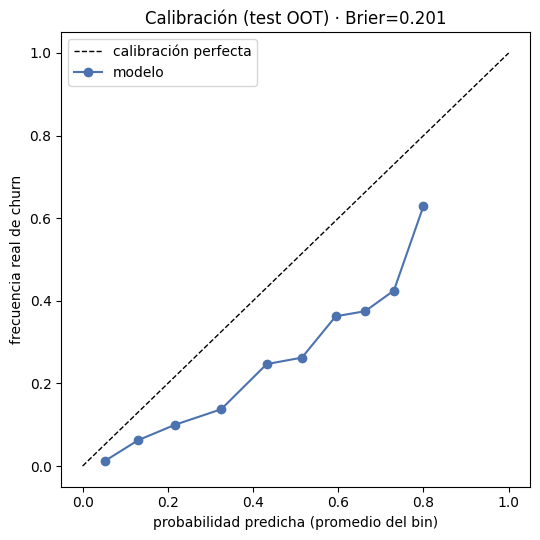

In [3]:
from sklearn.calibration import calibration_curve

frac_pos, mean_pred = calibration_curve(y_test, p_test, n_bins=10, strategy="quantile")
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot([0, 1], [0, 1], "k--", lw=1, label="calibración perfecta")
ax.plot(mean_pred, frac_pos, "o-", color="#4c72b0", label="modelo")
ax.set_xlabel("probabilidad predicha (promedio del bin)")
ax.set_ylabel("frecuencia real de churn")
ax.set_title(f"Calibración (test OOT) · Brier={brier:.3f}")
ax.legend(); plt.tight_layout(); plt.show()

## 2 · Discriminación: ROC y Precision-Recall

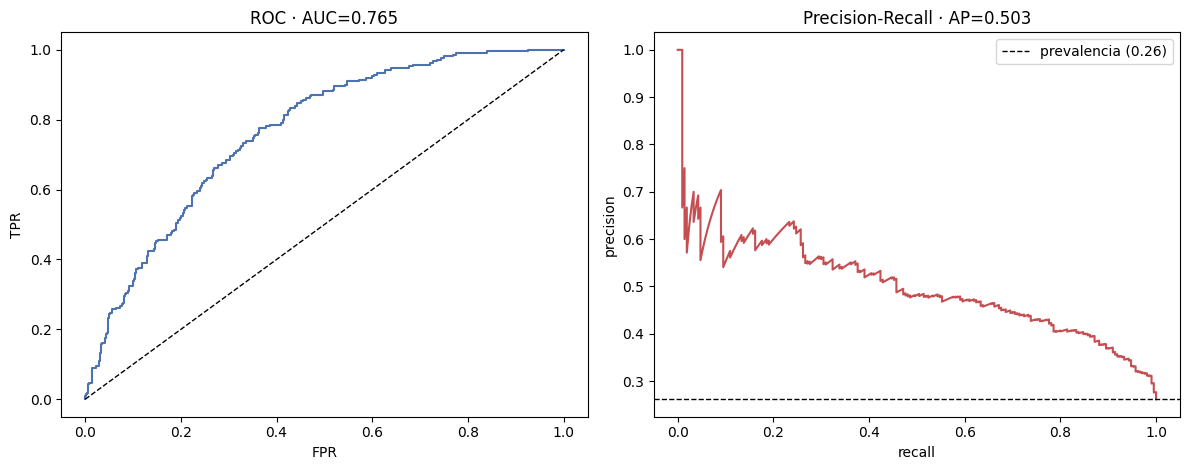

In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve

fpr, tpr, _ = roc_curve(y_test, p_test)
prec, rec, _ = precision_recall_curve(y_test, p_test)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
ax[0].plot(fpr, tpr, color="#4c72b0"); ax[0].plot([0, 1], [0, 1], "k--", lw=1)
ax[0].set_title(f"ROC · AUC={auc:.3f}"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
ax[1].plot(rec, prec, color="#c44e52")
ax[1].axhline(prev, color="k", ls="--", lw=1, label=f"prevalencia ({prev:.2f})")
ax[1].set_title(f"Precision-Recall · AP={ap:.3f}")
ax[1].set_xlabel("recall"); ax[1].set_ylabel("precision"); ax[1].legend()
plt.tight_layout(); plt.show()

## 3 · Ganancias y lift acumulados

Ordenamos a las vendedoras por score descendente (las que el modelo cree más en
riesgo primero) y acumulamos:

- **Curva de ganancias**: % de churners capturados vs % de la base contactada. La
  diagonal es el azar; cuanto más arriba la curva, mejor el *targeting*.
- **Curva de lift**: cuántas veces más churners encuentro en el top X% frente a
  elegir al azar.

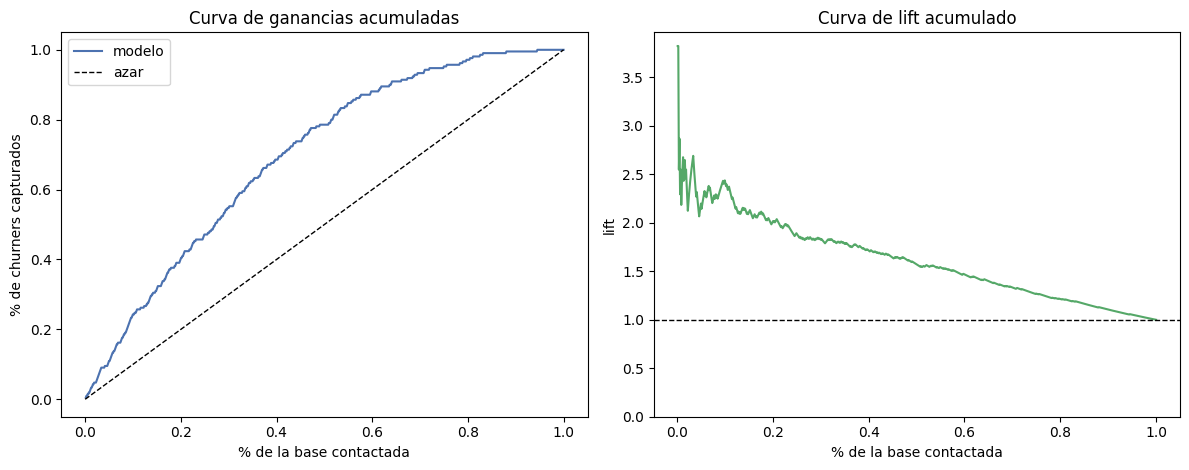

In [5]:
order = np.argsort(-p_test)
y_sorted = y_test[order]
total_pos = y_sorted.sum()
frac_contacted = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
frac_captured = np.cumsum(y_sorted) / total_pos
lift_curve = frac_captured / frac_contacted

fig, ax = plt.subplots(1, 2, figsize=(12, 4.8))
ax[0].plot(frac_contacted, frac_captured, color="#4c72b0", label="modelo")
ax[0].plot([0, 1], [0, 1], "k--", lw=1, label="azar")
ax[0].set_title("Curva de ganancias acumuladas")
ax[0].set_xlabel("% de la base contactada"); ax[0].set_ylabel("% de churners capturados")
ax[0].legend()
ax[1].plot(frac_contacted, lift_curve, color="#55a868")
ax[1].axhline(1, color="k", ls="--", lw=1)
ax[1].set_title("Curva de lift acumulado")
ax[1].set_xlabel("% de la base contactada"); ax[1].set_ylabel("lift")
ax[1].set_ylim(bottom=0)
plt.tight_layout(); plt.show()

## 4 · Puntos de operación

Dos formas de definir a quién contactar:
- **Por capacidad** (top X% por score): cuando el equipo tiene un presupuesto fijo
  de contactos.
- **Por umbral** de probabilidad (p. ej. t=0.5): cuando importa la confianza.

La tabla muestra, para cada opción: contactadas, churners capturados, precision,
recall y lift sobre la prevalencia.

`churners_azar` = churners esperados contactando al mismo nº de vendedoras **al azar** (`contactadas × prevalencia`); `extra` = capturados de más gracias al modelo (el lift expresado en nº de churners).

In [6]:
from sklearn.metrics import precision_score, recall_score

n = len(y_test)
rows = []
for k in [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]:
    m = int(np.ceil(k * n)); sel = order[:m]; tp = int(y_test[sel].sum())
    azar = m * prev                       # churners esperados contactando al azar
    rows.append({"regla": f"top {int(k*100)}%", "contactadas": m,
                 "churners": tp, "churners_azar": round(azar), "extra": round(tp - azar),
                 "precision": tp / m, "recall": tp / total_pos,
                 "lift_vs_prev": (tp / m) / prev})
for t in [0.5]:
    pr = (p_test >= t); m = int(pr.sum()); tp = int(y_test[pr].sum())
    azar = m * prev
    rows.append({"regla": f"umbral t={t}", "contactadas": m,
                 "churners": tp, "churners_azar": round(azar), "extra": round(tp - azar),
                 "precision": precision_score(y_test, pr, zero_division=0),
                 "recall": recall_score(y_test, pr),
                 "lift_vs_prev": (tp / m) / prev if m else np.nan})
ops = pd.DataFrame(rows)
print(ops.round(3).to_string(index=False))

       regla  contactadas  churners  churners_azar  extra  precision  recall  lift_vs_prev
      top 5%           41        23             11     12      0.561   0.110         2.145
     top 10%           81        51             21     30      0.630   0.243         2.408
     top 15%          121        67             32     35      0.554   0.319         2.117
     top 20%          161        85             42     43      0.528   0.405         2.019
     top 30%          241       115             63     52      0.477   0.548         1.825
     top 40%          322       144             84     60      0.447   0.686         1.710
     top 50%          402       165            105     60      0.410   0.786         1.569
umbral t=0.5          380       163             99     64      0.429   0.776         1.640


## 5 · Matriz de confusión (umbral t = 0.5)

Lectura para retención: **falsos negativos** = churners que no contactamos (la
pérdida que queremos evitar); **falsos positivos** = vendedoras sanas contactadas
(costo del contacto, usualmente bajo).

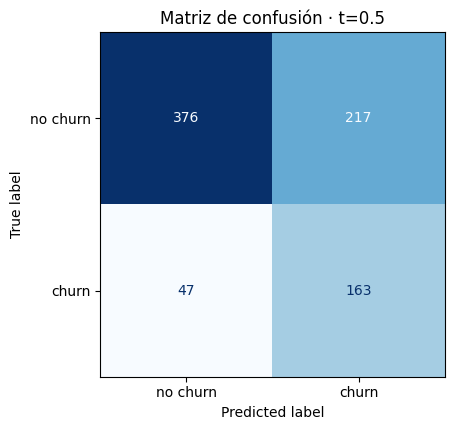

capturados (TP)=163 | perdidos (FN)=47 | falsa alarma (FP)=217 | sanos correctos (TN)=376


In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

t = 0.5
pred = (p_test >= t).astype(int)
cm = confusion_matrix(y_test, pred)
fig, ax = plt.subplots(figsize=(4.8, 4.4))
ConfusionMatrixDisplay(cm, display_labels=["no churn", "churn"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusión · t={t}")
plt.tight_layout(); plt.show()
tn, fp, fn, tp = cm.ravel()
print(f"capturados (TP)={tp} | perdidos (FN)={fn} | "
      f"falsa alarma (FP)={fp} | sanos correctos (TN)={tn}")

## 6 · Costo-beneficio (supuestos editables)

Traduce cada punto de operación a **valor neto esperado**. Los tres parámetros de
abajo son **supuestos** — reemplázalos con números reales del negocio:

- `COSTO_CONTACTO`: costo de contactar a una vendedora (llamada, incentivo).
- `VALOR_RETENCION`: margen futuro de retener a una churner real.
- `TASA_EXITO`: probabilidad de que el contacto efectivamente la retenga.

Valor neto = (churners capturados × `TASA_EXITO` × `VALOR_RETENCION`)
− (contactadas × `COSTO_CONTACTO`). El óptimo indica **hasta qué % conviene contactar**.

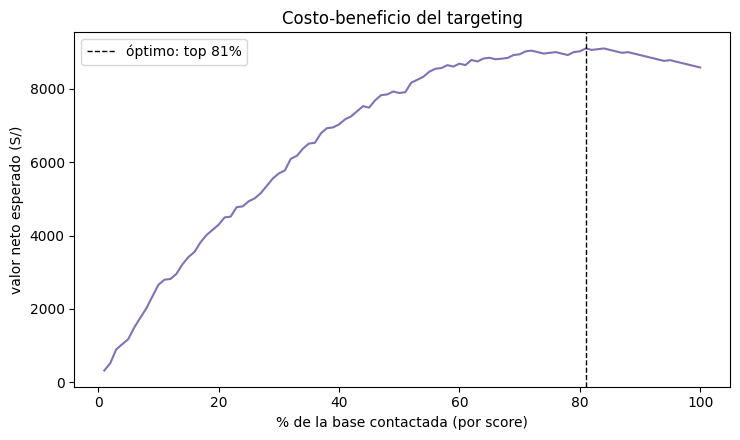

Óptimo: contactar top 81% (651 vendedoras) → captura 206 churners (98%) | valor neto S/ 9,105
NOTA: resultado dependiente de los supuestos de arriba — ajustar antes de decidir.


In [8]:
# --- SUPUESTOS: reemplazar con cifras reales del negocio ---
COSTO_CONTACTO = 5.0       # S/ por vendedora contactada
VALOR_RETENCION = 200.0    # S/ de margen por churner retenida
TASA_EXITO = 0.30          # prob. de retención efectiva al contactar a una churner real

fracs = np.linspace(0.01, 1.0, 100)
neto = []
for k in fracs:
    m = int(np.ceil(k * n)); tp = int(y_test[order[:m]].sum())
    neto.append(tp * TASA_EXITO * VALOR_RETENCION - m * COSTO_CONTACTO)
neto = np.array(neto)
k_opt = fracs[neto.argmax()]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(fracs * 100, neto, color="#8172b3")
ax.axvline(k_opt * 100, color="k", ls="--", lw=1,
           label=f"óptimo: top {k_opt*100:.0f}%")
ax.set_xlabel("% de la base contactada (por score)"); ax.set_ylabel("valor neto esperado (S/)")
ax.set_title("Costo-beneficio del targeting"); ax.legend()
plt.tight_layout(); plt.show()
m = int(np.ceil(k_opt * n)); tp = int(y_test[order[:m]].sum())
print(f"Óptimo: contactar top {k_opt*100:.0f}% ({m} vendedoras) → "
      f"captura {tp} churners ({tp/total_pos:.0%}) | valor neto S/ {neto.max():,.0f}")
print("NOTA: resultado dependiente de los supuestos de arriba — ajustar antes de decidir.")

## 7 · Síntesis

_(Completar tras ejecutar.)_

- **Calibración**: ¿se pueden usar las probabilidades como tal o solo como ranking?
  (si el Brier es alto / la curva se aleja de la diagonal → recalibrar).
- **Targeting**: el lift en el top decil y la curva de ganancias dicen el valor real
  del modelo. Argumento base: contactar al top X% por score captura *bastante más*
  churners que contactar al mismo X% al azar — esos puntos de recall incrementales
  son el valor del modelo.
- **Punto operativo recomendado**: elegir según capacidad del equipo de retención y
  el óptimo costo-beneficio (sec. 6) con los supuestos reales.
- **Techo de señal**: el modelo no es un oráculo (AUC ~0.76); su valor es *priorizar*,
  no *certificar*. Conviene cerrar con el plan de monitoreo (AUC/recall rolling) y
  reentrenamiento periódico.